- asof_pitcher_prev1_game_success_rate:바로 직전 1경기에서 얼마나 잘 던졌나 (초 따끈따끈한 최신 정보, 근데 딱 1경기라 운에 좀 좌우될 수 있음)
- asof_pitcher_prev3_game_success_rate	최근 3경기 성공률 (1경기보다 조금 더 안정적인 "요즘 컨디션")
- asof_pitcher_prev5_game_success_rate	최근 5경기 성공률 (더 안정적이지만, prev3랑 거의 같은 얘기라 겹치는 정보)
- asof_pitcher_prev1_game_middle_rate	최근 1경기에서 위험한 가운데로 던진 비율
- asof_pitcher_prev3_game_middle_rate	최근 3경기에서 가운데로 던진 비율
- asof_pitcher_prev5_game_middle_rate	최근 5경기에서 가운데로 던진 비율
- asof_batter_n	이 타자를 상대로 지금까지 몇 번 던져봤나 (표본 수, 신뢰도 척도)
- asof_batter_success_rate	이 타자를 상대할 때 성공률이 얼마나 되나 (상대하기 쉬운 타자인지)
- asof_batter_middle_rate	이 타자를 상대할 때 가운데로 몰리는 비율이 얼마나 되나

# 기초 통계량 보기

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

train = pd.read_csv("/content/train.csv")
print(train.shape)

(1475092, 49)


In [ ]:
train.tail()

,row_id,season,game_month,game_dayofweek,inning,top_bottom,game_type,balls_before,strikes_before,outs_before,...,asof_pitcher_prev3_game_middle_rate,asof_pitcher_prev5_game_middle_rate,asof_batter_n,asof_batter_success_rate,asof_batter_middle_rate,asof_pitcher_pitchmix_n,asof_pitcher_fastball_rate,asof_pitcher_breaking_rate,asof_pitcher_offspeed_rate,control_success
1475087,TRAIN_1475088,2024,10,5,10,B,F,3,0,1,...,0.107143,0.138889,2639,0.569913,0.130731,176,0.857955,0.130682,0.011364,1
1475088,TRAIN_1475089,2024,10,5,10,B,F,0,0,1,...,0.107143,0.138889,2710,0.525461,0.149815,177,0.858757,0.129944,0.011299,0
1475089,TRAIN_1475090,2024,10,5,10,B,F,0,1,1,...,0.107143,0.138889,2711,0.525267,0.150129,178,0.859551,0.129213,0.011236,1
1475090,TRAIN_1475091,2024,10,5,10,B,F,0,0,2,...,0.107143,0.138889,1021,0.625857,0.131244,179,0.860335,0.128492,0.011173,1
1475091,TRAIN_1475092,2024,10,5,10,B,F,1,0,2,...,0.107143,0.138889,1022,0.626223,0.131115,180,0.861111,0.127778,0.011111,1


In [ ]:
my_cols = [
    "asof_pitcher_prev1_game_success_rate",
    "asof_pitcher_prev3_game_success_rate",
    "asof_pitcher_prev5_game_success_rate",
    "asof_pitcher_prev1_game_middle_rate",
    "asof_pitcher_prev3_game_middle_rate",
    "asof_pitcher_prev5_game_middle_rate",
    "asof_batter_n",
    "asof_batter_success_rate",
    "asof_batter_middle_rate",
]

print("=== 기초 통계 ===")
print(train[my_cols].describe())

print("\n=== 결측치 비율(%) ===")
print(train[my_cols].isna().mean() * 100)

print("\n=== dtype 확인 ===")
print(train[my_cols].dtypes)

train = pd.read_csv(file_path, usecols=my_cols)
print("행 수:", len(train))

=== 기초 통계 ===
       asof_pitcher_prev1_game_success_rate  \
count                          1.445907e+06   
mean                           5.233543e-01   
std                            1.358860e-01   
min                            0.000000e+00   
25%                            4.432990e-01   
50%                            5.238100e-01   
75%                            6.052630e-01   
max                            1.000000e+00   

       asof_pitcher_prev3_game_success_rate  \
count                          1.445907e+06   
mean                           5.238475e-01   
std                            9.172289e-02   
min                            0.000000e+00   
25%                            4.657530e-01   
50%                            5.217390e-01   
75%                            5.799260e-01   
max                            1.000000e+00   

       asof_pitcher_prev5_game_success_rate  \
count                          1.445907e+06   
mean                           5.244112e-01 

- 결측치가 있다:  random 하게 있는건지, 아니면 특정 조건에서만 몰려있다든지 확인필요 (시즌 초에 많을 수도 있고 아니면 신인/ 새시즌 투수도 확인해봐야할 필요 있다고 판단)

In [ ]:
train["is_missing_prev1"] = train["asof_pitcher_prev1_game_success_rate"].isna()

other_cols = ["asof_batter_n", "asof_batter_success_rate", "asof_batter_middle_rate"]

print("=== 결측 여부에 따른 다른 컬럼들 평균 비교 ===")
print(train.groupby("is_missing_prev1")[other_cols].mean())

print("\n=== 결측 여부에 따른 다른 컬럼들 분포(describe) ===")
for col in other_cols:
    print(f"\n--- {col} ---")
    print(train.groupby("is_missing_prev1")[col].describe())

=== 결측 여부에 따른 다른 컬럼들 평균 비교 ===
                  asof_batter_n  asof_batter_success_rate  \
is_missing_prev1                                            
False               3300.634994                  0.539217   
True                1795.086037                  0.565310   

                  asof_batter_middle_rate  
is_missing_prev1                           
False                            0.140765  
True                             0.127642  

=== 결측 여부에 따른 다른 컬럼들 분포(describe) ===

--- asof_batter_n ---
                      count         mean          std  min    25%     50%  \
is_missing_prev1                                                            
False             1445907.0  3300.634994  3050.890824  0.0  813.0  2301.0   
True                29185.0  1795.086037  2552.703784  0.0   76.0   623.0   

                     75%      max  
is_missing_prev1                   
False             5047.0  13927.0  
True              2318.0  12455.0  

--- asof_batter_success_rate ---

- 결측(직전 경기 기록 없음)인 행들은, 단지 그 컬럼 하나만 비어있는 게 아니라, 상대 타자 정보도 적고(표본 부족), 그래서 다른 지표들도 값이 불안정하며(std가 2배), 그럼에도 평균 성공률은 더 높게 나오는 — 시즌 초반 특유의 '정보가 얕은 시기'라는 하나의 공통된 특징을 가지고 있다고 판단.

In [ ]:
my_cols = [
    "asof_pitcher_prev1_game_success_rate",
    "asof_pitcher_prev3_game_success_rate",
    "asof_pitcher_prev5_game_success_rate",
    "asof_pitcher_prev1_game_middle_rate",
    "asof_pitcher_prev3_game_middle_rate",
    "asof_pitcher_prev5_game_middle_rate",
    "asof_batter_n",
    "asof_batter_success_rate",
    "asof_batter_middle_rate",
]

train = pd.read_csv(file_path, usecols=my_cols + ["control_success", "game_month", "season"])
print(train.shape)
print(train.columns.tolist())

(1475092, 12)
['season', 'game_month', 'asof_pitcher_prev1_game_success_rate', 'asof_pitcher_prev3_game_success_rate', 'asof_pitcher_prev5_game_success_rate', 'asof_pitcher_prev1_game_middle_rate', 'asof_pitcher_prev3_game_middle_rate', 'asof_pitcher_prev5_game_middle_rate', 'asof_batter_n', 'asof_batter_success_rate', 'asof_batter_middle_rate', 'control_success']


In [ ]:
train["is_missing_prev1"] = train["asof_pitcher_prev1_game_success_rate"].isna()

print("=== 월별 결측 비율 ===")
print(train.groupby("game_month")["is_missing_prev1"].mean() * 100)

print("\n=== 시즌별 결측 비율 ===")
print(train.groupby("season")["is_missing_prev1"].mean() * 100)

=== 월별 결측 비율 ===
game_month
3     29.996894
4      3.185281
5      2.302121
6      1.224285
7      0.957961
8      0.968994
9      0.775527
10     0.261352
Name: is_missing_prev1, dtype: float64

=== 시즌별 결측 비율 ===
season
2019    5.171579
2020    1.583452
2021    1.514035
2022    1.188417
2023    1.108645
2024    1.435069
Name: is_missing_prev1, dtype: float64


- 3월(30.0%)에서 4월(3.2%)로 급감하는데, 이는 직전 경기 기록이 없는 시즌 초반 투수들 때문이며, 2019년(5.2%)이 다른 연도보다 높은 것도 데이터가 시작되는 첫 시즌이라 이전 기록이 아예 없었기 때문으로 해석. 이 패턴은 단순 대치보다 결측 여부 자체를 피처로 활용하는 방안을 고려

In [ ]:
tmp = train[["is_missing_prev1", "control_success"]].dropna()
print(tmp.groupby("is_missing_prev1")["control_success"].agg(["mean", "count"]))

                      mean    count
is_missing_prev1                   
False             0.523220  1445907
True              0.550831    29185


In [ ]:
april_only = train[train["game_month"] == 4]
print("=== 4월만 놓고 봤을 때 ===")
print(april_only.groupby("is_missing_prev1")["control_success"].agg(["mean", "count"]))

march_only = train[train["game_month"] == 3]
print("\n=== 3월만 놓고 봤을 때 ===")
print(march_only.groupby("is_missing_prev1")["control_success"].agg(["mean", "count"]))

=== 4월만 놓고 봤을 때 ===
                      mean   count
is_missing_prev1                  
False             0.525088  200056
True              0.552568    6582

=== 3월만 놓고 봤을 때 ===
                      mean  count
is_missing_prev1                 
False             0.528064  18030
True              0.559539   7726


- (직전 경기 기록 없음) 여부가 타겟과 관계있는지 확인한 결과, 결측 상황의 성공률이 오히려 2.8~3.2%p 더 높게 나타남. 월별로 통제해도 이 격차가 그대로 유지되어, 시기 효과가 아닌 (데이터셋 내 최초 등판이라 직전 경기 기록 자체가 없는 상황) 자체의 독립적 신호로 판단. 원인은 명확히 특정하기 어려우나, 시즌 첫 등판 투수 집단의 특성(예: 개막전/초반 로테이션에 우선 배치되는 검증된 투수 비중) 등 여러 가설이 가능하며, 결측을 단순 대치하기보다 피처로 명시적으로 반영하는 것을 제안

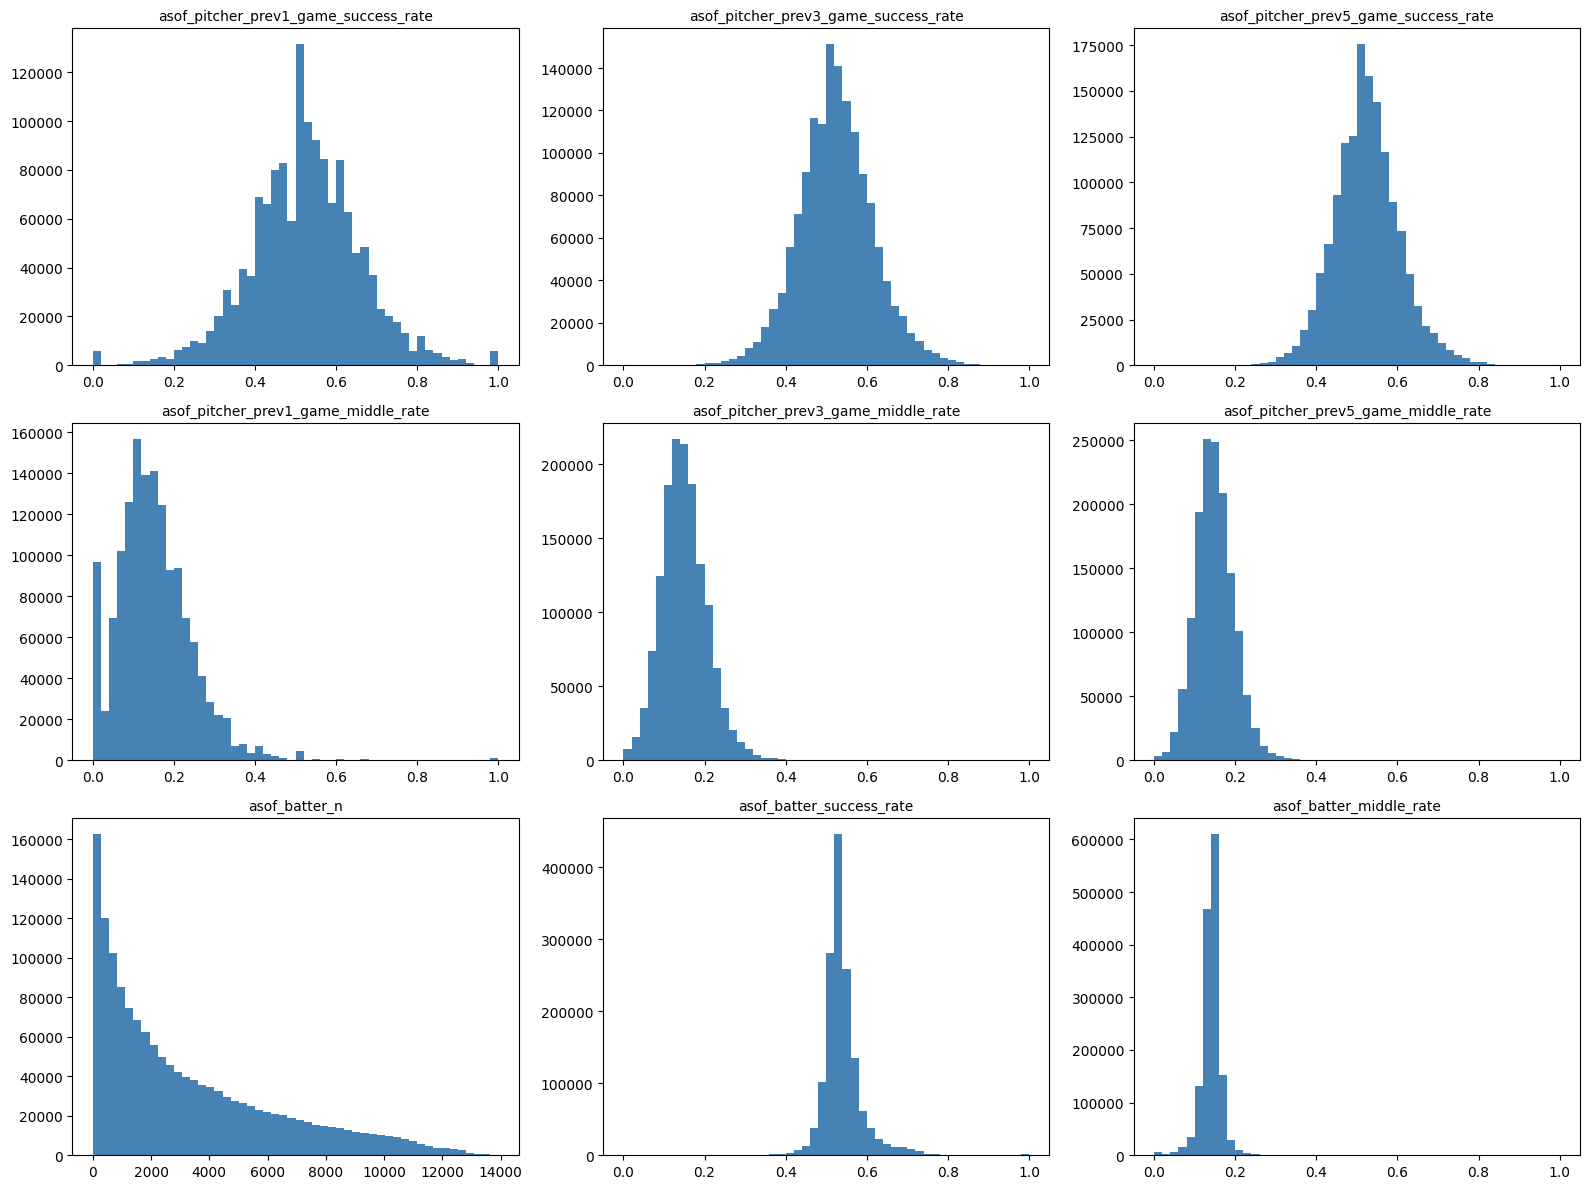

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, col in zip(axes.flat, my_cols):
    ax.hist(train[col].dropna(), bins=50, color="steelblue")
    ax.set_title(col, fontsize=10)
plt.tight_layout()
plt.show()

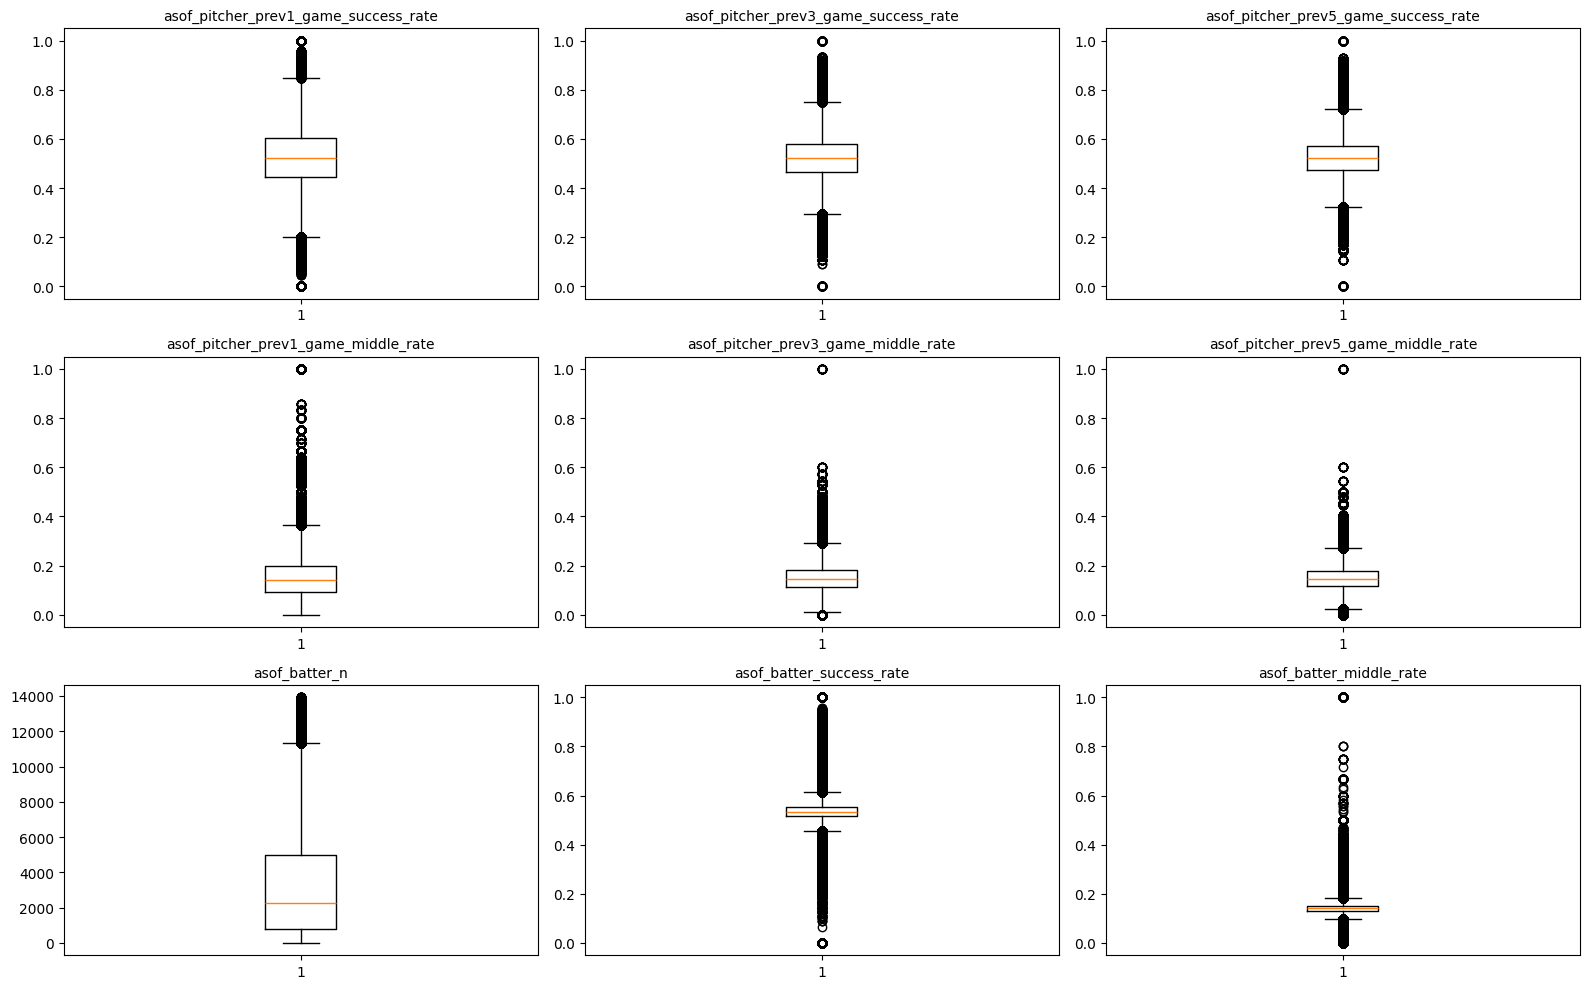

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(16, 10))
for ax, col in zip(axes.flat, my_cols):
    ax.boxplot(train[col].dropna(), vert=True)
    ax.set_title(col, fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
print("=== 기초 통계 (전체 데이터) ===")
print(train[my_cols].describe())

print("\n=== 결측치 비율(%) (전체 데이터) ===")
print(train[my_cols].isna().mean() * 100)

=== 기초 통계 (전체 데이터) ===
       asof_pitcher_prev1_game_success_rate  \
count                          1.445907e+06   
mean                           5.233543e-01   
std                            1.358860e-01   
min                            0.000000e+00   
25%                            4.432990e-01   
50%                            5.238100e-01   
75%                            6.052630e-01   
max                            1.000000e+00   

       asof_pitcher_prev3_game_success_rate  \
count                          1.445907e+06   
mean                           5.238475e-01   
std                            9.172289e-02   
min                            0.000000e+00   
25%                            4.657530e-01   
50%                            5.217390e-01   
75%                            5.799260e-01   
max                            1.000000e+00   

       asof_pitcher_prev5_game_success_rate  \
count                          1.445907e+06   
mean                           5.24

# 통계적으로 상관관계가 있나 살펴보기

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_classif

my_cols = [
    "asof_pitcher_prev1_game_success_rate",
    "asof_pitcher_prev3_game_success_rate",
    "asof_pitcher_prev5_game_success_rate",
    "asof_pitcher_prev1_game_middle_rate",
    "asof_pitcher_prev3_game_middle_rate",
    "asof_pitcher_prev5_game_middle_rate",
    "asof_batter_n",
    "asof_batter_success_rate",
    "asof_batter_middle_rate",
]

pearson = train[my_cols + ["control_success"]].corr(method="pearson")["control_success"].drop("control_success")

spearman = train[my_cols + ["control_success"]].corr(method="spearman")["control_success"].drop("control_success")

sample_idx = train.sample(50_000, random_state=42).index
X_mi = train.loc[sample_idx, my_cols].fillna(train[my_cols].median())
y_mi = train.loc[sample_idx, "control_success"]

mi_scores = mutual_info_classif(
    X_mi, y_mi,
    discrete_features=False,
    random_state=42,
    n_neighbors=3,
)
mi = pd.Series(mi_scores, index=my_cols)

compare = pd.DataFrame({
    "pearson": pearson,
    "spearman": spearman,
    "mutual_info": mi,
})
compare["pearson_abs"] = compare["pearson"].abs()
compare = compare.sort_values("pearson_abs", ascending=False)

print(compare[["pearson", "spearman", "mutual_info"]])

                                       pearson  spearman  mutual_info
asof_pitcher_prev5_game_success_rate  0.081569  0.078374     0.007244
asof_pitcher_prev3_game_success_rate  0.077776  0.074685     0.005276
asof_pitcher_prev1_game_success_rate  0.061689  0.063024     0.005098
asof_batter_success_rate              0.058946  0.052926     0.000000
asof_batter_n                        -0.036276 -0.040470     0.001743
asof_batter_middle_rate              -0.033821 -0.038933     0.003054
asof_pitcher_prev5_game_middle_rate  -0.031952 -0.032510     0.007954
asof_pitcher_prev3_game_middle_rate  -0.028296 -0.028826     0.004028
asof_pitcher_prev1_game_middle_rate  -0.019460 -0.020018     0.001387


- 9개 변수 모두 피어슨과 스피어만이 거의 일치해서 비선형성은 거의 없는 것으로 확인했고, success_rate 계열이 middle_rate 계열보다, 그리고 표본이 클수록(prev5 > prev3 > prev1) 신호가 더 강하게 나타남

In [ ]:
def correlation_ratio(categories, values):
    categories = pd.Series(categories).astype(str)
    values = pd.Series(values)
    ss_between = 0
    grand_mean = values.mean()
    for cat in categories.unique():
        group = values[categories == cat]
        ss_between += len(group) * (group.mean() - grand_mean) ** 2
    ss_total = ((values - grand_mean) ** 2).sum()
    return (ss_between / ss_total) ** 0.5 if ss_total > 0 else 0.0

results = {}
for col in my_cols:
    tmp = train[[col, "control_success"]].dropna()
    try:
        bins = pd.qcut(tmp[col], q=10, duplicates="drop")
    except ValueError:
        bins = pd.cut(tmp[col], bins=min(10, tmp[col].nunique()))
    results[col] = correlation_ratio(bins, tmp["control_success"])

eta = pd.Series(results).sort_values(ascending=False)

compare["eta"] = eta
compare["eta_rank"] = compare["eta"].rank(ascending=False)
compare["pearson_rank"] = compare["pearson_abs"].rank(ascending=False)
compare["gap"] = compare["pearson_rank"] - compare["eta_rank"]

print(compare[["pearson_abs", "spearman", "mutual_info", "eta", "gap"]].sort_values("eta", ascending=False))

                                      pearson_abs  spearman  mutual_info  \
asof_pitcher_prev5_game_success_rate     0.081569  0.078374     0.007244   
asof_pitcher_prev3_game_success_rate     0.077776  0.074685     0.005276   
asof_pitcher_prev1_game_success_rate     0.061689  0.063024     0.005098   
asof_batter_success_rate                 0.058946  0.052926     0.000000   
asof_batter_middle_rate                  0.033821 -0.038933     0.003054   
asof_batter_n                            0.036276 -0.040470     0.001743   
asof_pitcher_prev5_game_middle_rate      0.031952 -0.032510     0.007954   
asof_pitcher_prev3_game_middle_rate      0.028296 -0.028826     0.004028   
asof_pitcher_prev1_game_middle_rate      0.019460 -0.020018     0.001387   

                                           eta  gap  
asof_pitcher_prev5_game_success_rate  0.080122  0.0  
asof_pitcher_prev3_game_success_rate  0.077005  0.0  
asof_pitcher_prev1_game_success_rate  0.063850  0.0  
asof_batter_success_rat

=== 담당 5 컬럼 쌍별 상관관계 (전체) ===
asof_pitcher_prev3_game_success_rate  asof_pitcher_prev5_game_success_rate    0.882157
asof_pitcher_prev3_game_middle_rate   asof_pitcher_prev5_game_middle_rate     0.846332
asof_pitcher_prev1_game_success_rate  asof_pitcher_prev3_game_success_rate    0.661840
asof_pitcher_prev1_game_middle_rate   asof_pitcher_prev3_game_middle_rate     0.595055
asof_pitcher_prev1_game_success_rate  asof_pitcher_prev5_game_success_rate    0.573480
asof_batter_success_rate              asof_batter_middle_rate                 0.535574
asof_pitcher_prev1_game_middle_rate   asof_pitcher_prev5_game_middle_rate     0.501348
asof_pitcher_prev1_game_success_rate  asof_pitcher_prev1_game_middle_rate     0.434969
asof_pitcher_prev5_game_success_rate  asof_pitcher_prev5_game_middle_rate     0.432060
asof_pitcher_prev3_game_success_rate  asof_pitcher_prev3_game_middle_rate     0.429235
                                      asof_pitcher_prev5_game_middle_rate     0.380635
asof_pitcher_p

/tmp/ipykernel_976/3875485018.py:35: UserWarning: Glyph 45812 (\N{HANGUL SYLLABLE DAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_976/3875485018.py:35: UserWarning: Glyph 45817 (\N{HANGUL SYLLABLE DANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_976/3875485018.py:35: UserWarning: Glyph 52972 (\N{HANGUL SYLLABLE KEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_976/3875485018.py:35: UserWarning: Glyph 47100 (\N{HANGUL SYLLABLE REOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_976/3875485018.py:35: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_976/3875485018.py:35: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_976/3875485018.py:35: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  plt.tight_lay

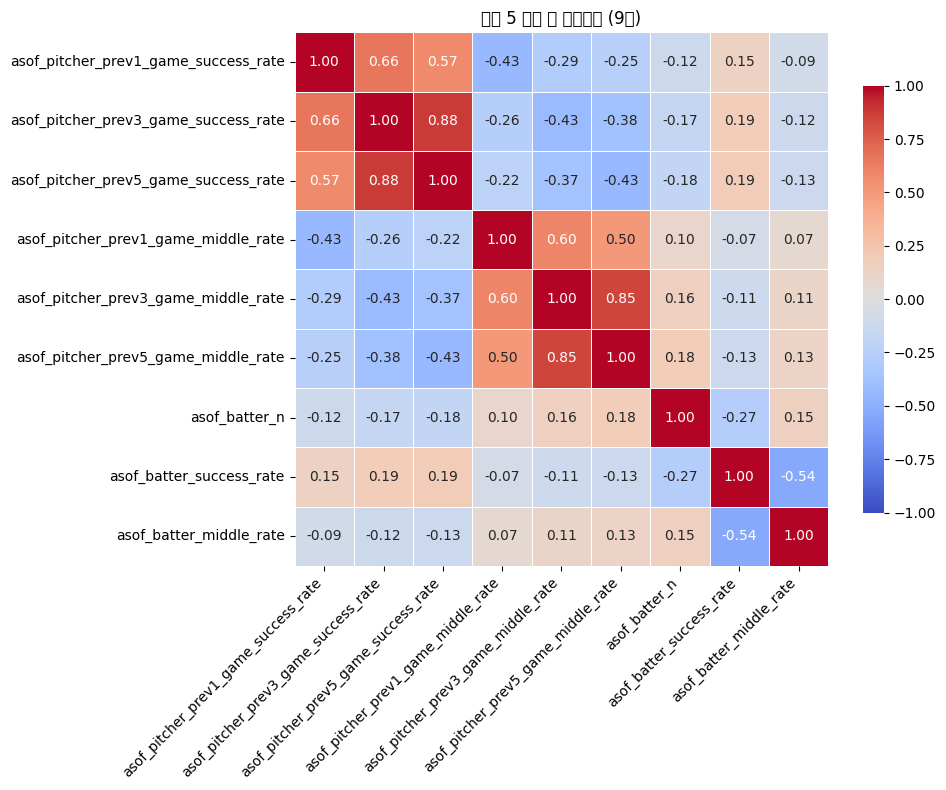

In [ ]:
import seaborn as sns

feat_corr = train[my_cols].corr().abs()

pairs = (
    feat_corr.where(np.triu(np.ones(feat_corr.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)

print("=== 담당 5 컬럼 쌍별 상관관계 (전체) ===")
print(pairs)

print("\n=== 0.7 이상 (중복 후보) ===")
print(pairs[pairs > 0.7])


feat_corr_full = train[my_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    feat_corr_full,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)
plt.title("담당 5 컬럼 간 상관관계 (9개)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

- prev3_success_rate ↔ prev5_success_rate: 0.88 (진한 빨강)
- prev3_middle_rate ↔ prev5_middle_rate: 0.85 (진한 빨강)

- 히트맵에서 prev3-prev5 두 쌍만 0.7을 넘는 진한 빨강으로 뚜렷하게 나타났고, success_rate와 middle_rate 두 계열은 서로 반대 방향(음의 상관) 블록 구조를 보임. 타자 이력의 success-middle 반비례(-0.54)가 투수 이력보다 더 강함
-> asof_batter_success_rate랑 asof_batter_middle_rate, 이 둘을 나중에 모델에 같이 넣을 때는 조심

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

final_cols = [
    "asof_pitcher_prev1_game_success_rate",
    "asof_pitcher_prev3_game_success_rate",
    "asof_pitcher_prev1_game_middle_rate",
    "asof_pitcher_prev3_game_middle_rate",
    "asof_batter_n",
    "asof_batter_success_rate",
    "asof_batter_middle_rate",
]

def get_importance(X, y, feature_names, label):
    rf = RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_leaf=200, n_jobs=-1, random_state=42)
    rf.fit(X, y)
    imp = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)
    print(f"\n=== {label} ===")
    print(imp)
    return imp

y_full = train["control_success"]

# ---- 방식 1: 결측 행 그냥 제거 (dropna) ----
tmp1 = train[final_cols + ["control_success"]].dropna()
imp1 = get_importance(tmp1[final_cols], tmp1["control_success"], final_cols, "방식 1: dropna (행 제거)")
print("남은 행 수:", len(tmp1), "/ 전체", len(train))

# ---- 방식 2: 중앙값으로 단순 대치 ----
X2 = train[final_cols].fillna(train[final_cols].median())
imp2 = get_importance(X2, y_full, final_cols, "방식 2: 중앙값 대치만")

# ---- 방식 3: 결측 여부 피처 추가 + 중앙값 대치 ----
X3 = train[final_cols].copy()
missing_flag_cols = []
for col in final_cols:
    if X3[col].isna().sum() > 0:
        flag_col = f"{col}_is_missing"
        X3[flag_col] = X3[col].isna().astype(int)
        missing_flag_cols.append(flag_col)
X3 = X3.fillna(X3.median())
feature_names_3 = final_cols + missing_flag_cols
imp3 = get_importance(X3, y_full, feature_names_3, "방식 3: 결측여부 피처 + 중앙값 대치")


=== 방식 1: dropna (행 제거) ===
asof_pitcher_prev3_game_success_rate    0.371360
asof_batter_success_rate                0.213547
asof_pitcher_prev1_game_success_rate    0.207499
asof_batter_middle_rate                 0.077302
asof_batter_n                           0.070618
asof_pitcher_prev3_game_middle_rate     0.035574
asof_pitcher_prev1_game_middle_rate     0.024101
dtype: float64
남은 행 수: 1445238 / 전체 1475092

=== 방식 2: 중앙값 대치만 ===
asof_pitcher_prev3_game_success_rate    0.358734
asof_batter_success_rate                0.232717
asof_pitcher_prev1_game_success_rate    0.200298
asof_batter_middle_rate                 0.078984
asof_batter_n                           0.072182
asof_pitcher_prev3_game_middle_rate     0.033763
asof_pitcher_prev1_game_middle_rate     0.023322
dtype: float64

=== 방식 3: 결측여부 피처 + 중앙값 대치 ===
asof_pitcher_prev3_game_success_rate               0.358677
asof_batter_success_rate                           0.219881
asof_pitcher_prev1_game_success_rate               

- 핵심 3인방 (전체 중요도의 약 78%): prev3_success_rate > batter_success_rate > prev1_success_rate

- 보조 4개: batter_middle_rate, batter_n, prev3_middle_rate, prev1_middle_rate — 개별로는 약하지만, 팀 공유 세션에서 다른 그룹 변수랑 곱하거나 조합하면(저희가 팀 전체에서 pressure_x_recent_form 만들었던 것처럼) 살아날 가능성 있는 재료들

- 또 다른 결측치 대체 방법이 있으면 그거 써봐도 될듯..(일단 임의로 해본 것)

In [ ]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

final_cols = [
    "asof_pitcher_prev3_game_success_rate",
    "asof_batter_success_rate",
    "asof_pitcher_prev1_game_success_rate",
    "asof_batter_middle_rate",
    "asof_batter_n",
    "asof_pitcher_prev3_game_middle_rate",
    "asof_pitcher_prev1_game_middle_rate",
]

vif_data = train[final_cols].dropna()
vif_data_with_const = sm.add_constant(vif_data)

vif_result = pd.DataFrame()
vif_result["변수"] = vif_data_with_const.columns
vif_result["VIF"] = [
    variance_inflation_factor(vif_data_with_const.values, i)
    for i in range(vif_data_with_const.shape[1])
]

vif_result = vif_result[vif_result["변수"] != "const"].sort_values("VIF", ascending=False)
print(vif_result)

                                     변수       VIF
1  asof_pitcher_prev3_game_success_rate  2.207904
3  asof_pitcher_prev1_game_success_rate  2.201951
6   asof_pitcher_prev3_game_middle_rate  1.914323
7   asof_pitcher_prev1_game_middle_rate  1.913925
2              asof_batter_success_rate  1.502898
4               asof_batter_middle_rate  1.412983
5                         asof_batter_n  1.103623


- 최종 결론
- 9개 중 7개 유지 (prev5 계열 2개는 prev3와 중복이라 제거)
- 핵심 3인방: prev3_success_rate > batter_success_rate > prev1_success_rate (전체 중요도 78%)
- VIF 전부 1~2.2로 다중공선성 문제없음 확인